# Gravitational Wave Noise Filter

A 1D convolutional autoencoder trained on real LIGO strain data to suppress detector noise.

**Stack:** Python · PyTorch · GWpy · GWOSC · SciPy · T4 GPU (Colab)

In [2]:
!pip install gwpy gwosc pycbc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 8.3 MB/s eta 0:00:00


## 1. Environment Setup

Install LIGO-specific packages. NumPy, SciPy, Matplotlib, and PyTorch are pre-installed on Colab.

In [3]:
import gwpy
import gwosc
import pycbc
import numpy as np
import scipy
import matplotlib
import torch

print(f"gwpy: {gwpy.__version__}")
print(f"gwosc: {gwosc.__version__}")
print(f"numpy: {np.__version__}")
print(f"scipy: {scipy.__version__}")
print(f"torch: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

/usr/local/lib/python3.12/dist-packages/gwpy/time/_ligotimegps.py:42: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


gwpy: 4.0.1
gwosc: 0.8.2
numpy: 2.0.2
scipy: 1.16.3
torch: 2.11.0+cu128
GPU available: True


## 2. Data Fetching

Fetch 32s of H1 (Hanford) strain data centered on GW150914 — the first ever detected gravitational wave (Sept 14, 2015).

In [ ]:
from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries

gps_time = event_gps('GW150914')
print(f"GW150914 GPS time: {gps_time}")

strain = TimeSeries.fetch_open_data('H1', gps_time - 16, gps_time + 16)

print(f"Sample rate: {strain.sample_rate}")
print(f"Total samples: {len(strain)}")
print(f"Duration: {len(strain) / strain.sample_rate.value} seconds")

GW150914 GPS time: 1126259462.4
Sample rate: 4096.0 Hz
Total samples: 131072
Duration: 32.0 seconds


## 3. Raw Strain Visualization

The gravitational wave signal is completely invisible in raw data — buried ~1000× below the noise floor.

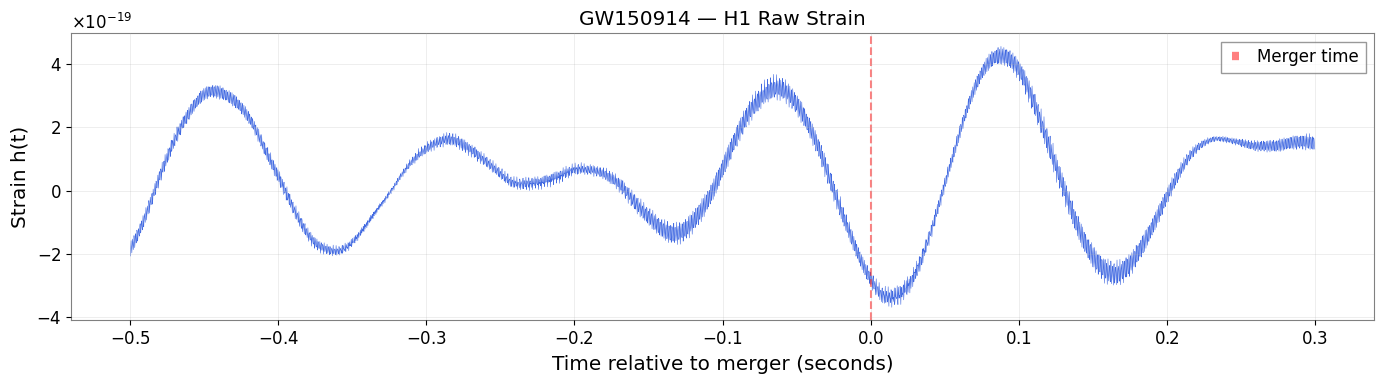

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

time = strain.times.value - gps_time

fig, ax = plt.subplots(figsize=(14, 4))
mask = (time > -0.5) & (time < 0.3)

ax.plot(time[mask], strain.value[mask], linewidth=0.4, color='royalblue')
ax.set_xlabel('Time relative to merger (seconds)')
ax.set_ylabel('Strain h(t)')
ax.set_title('GW150914 — H1 Raw Strain')
ax.axvline(0, color='red', linestyle='--', alpha=0.5, label='Merger time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Preprocessing Pipeline

Reveal the signal:
- **Whitening** — flattens noise PSD so all frequencies contribute equally
- **Bandpass 35–350 Hz** — removes seismic noise (low) and shot noise (high)

Strain value range: -7.045e-19 to 7.706e-19
Standard deviation: 2.216e-19

After whitening — std: 1.185
After bandpass — std: 0.365


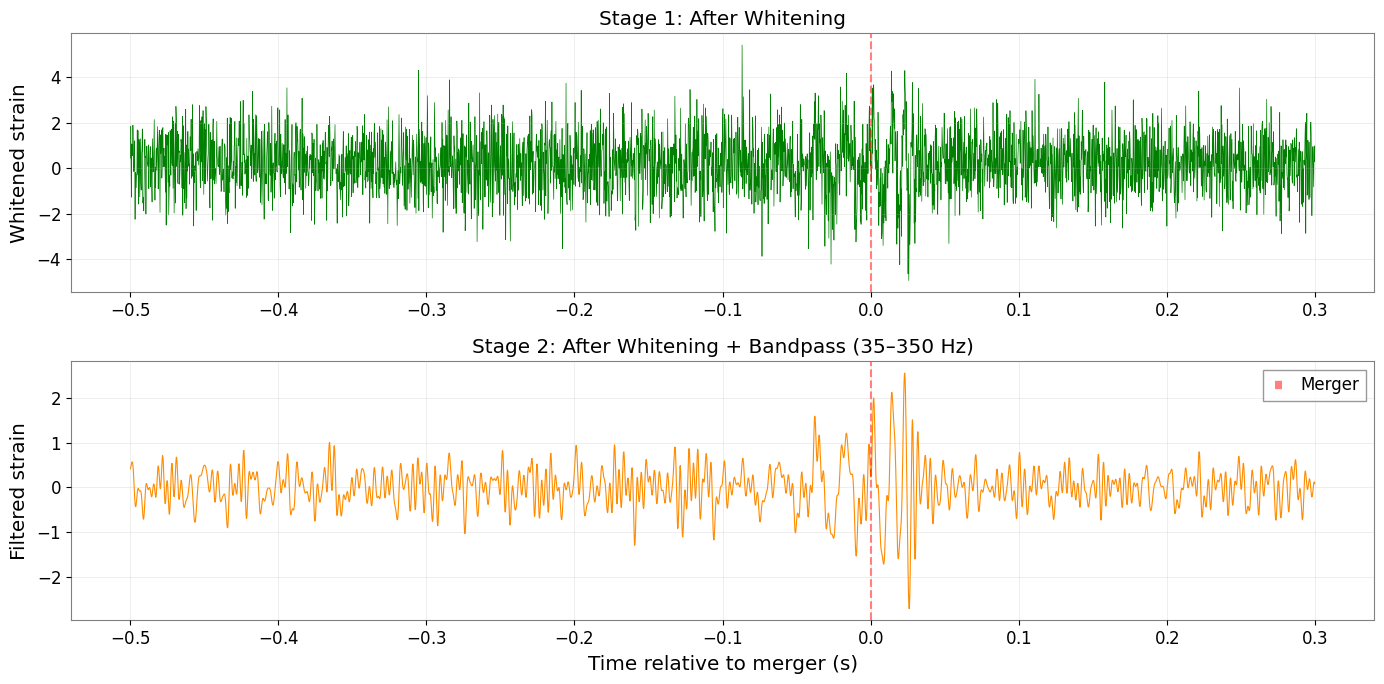

In [ ]:
print(f"Strain value range: {strain.value.min():.3e} to {strain.value.max():.3e}")
print(f"Standard deviation: {strain.value.std():.3e}")


white = strain.whiten(4, 2)  # 4s FFT window, 2s overlap
print(f"\nAfter whitening — std: {white.value.std():.3f}")

bp = white.bandpass(35, 350)
print(f"After bandpass — std: {bp.value.std():.3f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
time = strain.times.value - gps_time
mask = (time > -0.5) & (time < 0.3)

axes[0].plot(time[mask], white.value[mask], linewidth=0.5, color='green')
axes[0].set_title('Stage 1: After Whitening')
axes[0].set_ylabel('Whitened strain')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

axes[1].plot(time[mask], bp.value[mask], linewidth=0.8, color='darkorange')
axes[1].set_title('Stage 2: After Whitening + Bandpass (35–350 Hz)')
axes[1].set_ylabel('Filtered strain')
axes[1].set_xlabel('Time relative to merger (s)')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.5, label='Merger')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Training Data

Fetch 5 quiet noise-only segments (no known GW events). The autoencoder trains purely on noise — it never sees a real signal during training.

In [ ]:

QUIET_SEGMENTS = [
    (1126259200 - 500, 1126259200 - 200),   
    (1126260000, 1126260300),                
    (1135136000, 1135136300),                
    (1167559936, 1167560236),                
    (1185432918, 1185433218),               
]

training_strains = []

for i, (start, end) in enumerate(QUIET_SEGMENTS):
    print(f"Fetching segment {i+1}/{len(QUIET_SEGMENTS)}...")
    try:
        seg = TimeSeries.fetch_open_data('H1', start, end)
        training_strains.append(seg)
        print(f"  OK — {len(seg)} samples, {len(seg)/seg.sample_rate.value:.1f}s")
    except Exception as e:
        print(f"  Failed: {e}")

print(f"\nTotal segments fetched: {len(training_strains)}")

Fetching segment 1/5...
  OK — 1228800 samples, 300.0s
Fetching segment 2/5...
  OK — 1228800 samples, 300.0s
Fetching segment 3/5...
  OK — 1228800 samples, 300.0s
Fetching segment 4/5...
  OK — 1228800 samples, 300.0s
Fetching segment 5/5...
  OK — 1228800 samples, 300.0s

Total segments fetched: 5


## 6. Segmentation

Chop each 300s segment into 1-second Tukey-windowed overlapping windows (4096 samples, 50% overlap). 2,995 total training windows.

In [ ]:
from scipy.signal import butter, filtfilt, windows as scipy_windows
import numpy as np

def preprocess_segment(strain_timeseries):
    """Whiten + bandpass a GWpy TimeSeries, return numpy array."""
    white = strain_timeseries.whiten(4, 2)
    bp = white.bandpass(35, 350)
    arr = bp.value.astype(np.float32)
    arr = (arr - arr.mean()) / (arr.std() + 1e-10)
    return arr

def make_windows(arr, segment_length=4096, hop=2048):
    """Chop array into overlapping fixed-length windows."""
    segments = []
    start = 0
    win = scipy_windows.tukey(segment_length, alpha=0.2)
    while start + segment_length <= len(arr):
        seg = arr[start : start + segment_length] * win
        segments.append(seg)
        start += hop
    return np.array(segments, dtype=np.float32)

all_windows = []

for i, seg in enumerate(training_strains):
    print(f"Processing segment {i+1}/5...")
    processed = preprocess_segment(seg)
    windows = make_windows(processed)
    all_windows.append(windows)
    print(f"  → {len(windows)} windows")

X_train = np.concatenate(all_windows, axis=0)
print(f"\nTotal training windows: {X_train.shape[0]}")
print(f"Each window shape: {X_train.shape[1]} samples = 1 second at 4096 Hz")
print(f"Training data array shape: {X_train.shape}")

Processing segment 1/5...
  → 599 windows
Processing segment 2/5...
  → 599 windows
Processing segment 3/5...
  → 599 windows
Processing segment 4/5...
  → 599 windows
Processing segment 5/5...
  → 599 windows

Total training windows: 2995
Each window shape: 4096 samples = 1 second at 4096 Hz
Training data array shape: (2995, 4096)


## 7. PyTorch Dataset & DataLoader

Input = Target = same noise window. Self-supervised autoencoder training. 85% train / 15% validation split.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class GWNoiseDataset(Dataset):
    """
    Dataset of pure noise windows.

    For a denoising autoencoder, input = target = the same clean noise window.
    The model learns to reconstruct noise. When a signal appears, it can't
    reconstruct it perfectly — that residual reveals the signal.
    """
    def __init__(self, windows):
        self.data = torch.tensor(windows).unsqueeze(1)  

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        return x, x  

n_total = len(X_train)
n_val = int(0.15 * n_total)
n_train = n_total - n_val

indices = np.random.permutation(n_total)
train_idx = indices[:n_train]
val_idx = indices[n_train:]

train_dataset = GWNoiseDataset(X_train[train_idx])
val_dataset = GWNoiseDataset(X_train[val_idx])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Train batches:      {len(train_loader)}")

x_batch, y_batch = next(iter(train_loader))
print(f"\nBatch shape: {x_batch.shape}")  
print(f"dtype: {x_batch.dtype}")

Training samples:   2546
Validation samples: 449
Train batches:      80

Batch shape: torch.Size([32, 1, 4096])
dtype: torch.float32


## 8. Model Architecture

1D Convolutional Autoencoder (25,569 parameters):
- **Encoder:** 3× Conv1d + BatchNorm + ReLU, stride=2 → bottleneck (64, 512)
- **Decoder:** 3× ConvTranspose1d → reconstructs (1, 4096)

In [ ]:
import torch.nn as nn

class GWAutoencoder(nn.Module):
    """
    1D Convolutional Autoencoder for LIGO noise.

    Encoder: compresses (1, 4096) → (64, 512) bottleneck
    Decoder: reconstructs (64, 512) → (1, 4096)

    The bottleneck forces the network to learn a compact representation
    of typical noise patterns. Signals are out-of-distribution and
    won't be reconstructed well — that residual reveals them.
    """
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=16, stride=2, padding=7),  
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=8, stride=2, padding=3),  
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=4, stride=2, padding=1),   
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),  
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.ConvTranspose1d(32, 16, kernel_size=8, stride=2, padding=3),  
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.ConvTranspose1d(16, 1, kernel_size=16, stride=2, padding=7),  
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GWAutoencoder().to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Device: {device}")
print(f"Total parameters: {total_params:,}")

model.eval()
with torch.no_grad():
    test_input = x_batch.to(device)
    test_output = model(test_input)
    print(f"Input shape:  {test_input.shape}")
    print(f"Output shape: {test_output.shape}")
    print(f"Shapes match: {test_input.shape == test_output.shape}")

Device: cuda
Total parameters: 25,569
Input shape:  torch.Size([32, 1, 4096])
Output shape: torch.Size([32, 1, 4096])
Shapes match: True


## 9. First Training Attempt

Initial run — NaN loss detected due to NaN values in training data from whitening edge effects.

Epoch   5/50 | Train Loss: nan | Val Loss: nan
Epoch  10/50 | Train Loss: nan | Val Loss: nan
Epoch  15/50 | Train Loss: nan | Val Loss: nan
Epoch  20/50 | Train Loss: nan | Val Loss: nan
Epoch  25/50 | Train Loss: nan | Val Loss: nan
Epoch  30/50 | Train Loss: nan | Val Loss: nan
Epoch  35/50 | Train Loss: nan | Val Loss: nan
Epoch  40/50 | Train Loss: nan | Val Loss: nan
Epoch  45/50 | Train Loss: nan | Val Loss: nan
Epoch  50/50 | Train Loss: nan | Val Loss: nan

Training complete.


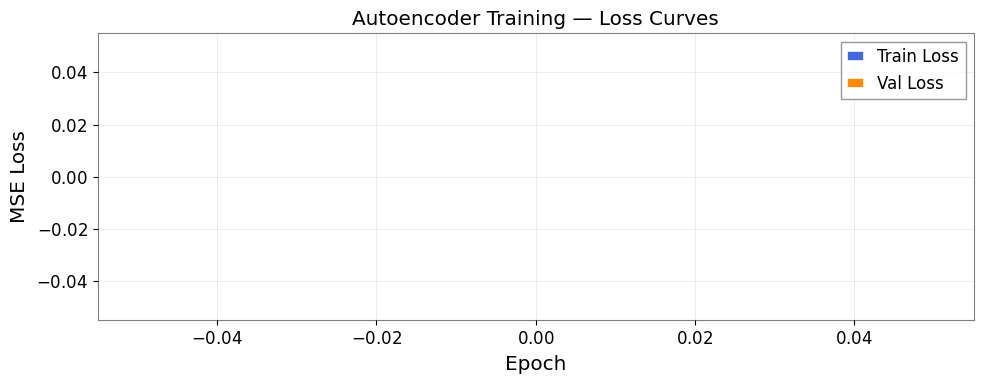

In [ ]:
import torch.optim as optim
from tqdm import tqdm

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

EPOCHS = 50
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)

        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, x_batch)  
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    model.eval()
    val_batch_losses = []

    with torch.no_grad():
        for x_batch, _ in val_loader:
            x_batch = x_batch.to(device)
            output = model(x_batch)
            loss = criterion(output, x_batch)
            val_batch_losses.append(loss.item())

    val_loss = np.mean(val_batch_losses)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

print("\nTraining complete.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train Loss', color='royalblue')
ax.plot(val_losses, label='Val Loss', color='darkorange')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Autoencoder Training — Loss Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Debug: NaN Detection

Diagnosing source of NaN values. Found in raw training data, not in the model.

In [ ]:
print(f"NaN in X_train: {np.isnan(X_train).any()}")
print(f"Inf in X_train: {np.isinf(X_train).any()}")
print(f"Max value: {np.abs(X_train).max():.4f}")
print(f"Mean: {X_train.mean():.4f}, Std: {X_train.std():.4f}")

model2 = GWAutoencoder().to(device)
x_test = next(iter(train_loader))[0].to(device)
print(f"\nInput NaN: {torch.isnan(x_test).any()}")

z = model2.encoder(x_test)
print(f"After encoder — NaN: {torch.isnan(z).any()}, max: {z.abs().max():.4f}")

out = model2.decoder(z)
print(f"After decoder — NaN: {torch.isnan(out).any()}, max: {out.abs().max():.4f}")

NaN in X_train: True
Inf in X_train: False
Max value: nan
Mean: nan, Std: nan

Input NaN: True
After encoder — NaN: True, max: nan
After decoder — NaN: True, max: nan


### Fix: Safe Preprocessing

Clip NaN/Inf values before normalization. Rebuild clean training set — 2,995 windows, all verified NaN-free.

In [ ]:
def preprocess_segment_safe(strain_timeseries):
    """Whiten + bandpass with NaN protection."""
    white = strain_timeseries.whiten(4, 2)
    bp = white.bandpass(35, 350)
    arr = bp.value.astype(np.float32)

    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

    std = arr.std()
    if std > 1e-10:
        arr = (arr - arr.mean()) / std

    return arr

def make_windows_safe(arr, segment_length=4096, hop=2048):
    """Skip any window that still contains NaN after preprocessing."""
    segments = []
    start = 0
    win = scipy_windows.tukey(segment_length, alpha=0.2)
    while start + segment_length <= len(arr):
        seg = arr[start : start + segment_length] * win
        if not np.isnan(seg).any():  # only keep clean windows
            segments.append(seg)
        start += hop
    return np.array(segments, dtype=np.float32)

all_windows = []

for i, seg in enumerate(training_strains):
    print(f"Processing segment {i+1}/5...")
    processed = preprocess_segment_safe(seg)
    windows = make_windows_safe(processed)
    all_windows.append(windows)
    print(f"  → {len(windows)} clean windows")

X_train = np.concatenate(all_windows, axis=0)

print(f"\nTotal clean windows: {X_train.shape[0]}")
print(f"NaN in X_train: {np.isnan(X_train).any()}")
print(f"Max value: {np.abs(X_train).max():.4f}")

Processing segment 1/5...
  → 599 clean windows
Processing segment 2/5...
  → 599 clean windows
Processing segment 3/5...
  → 599 clean windows
Processing segment 4/5...
  → 599 clean windows
Processing segment 5/5...
  → 599 clean windows

Total clean windows: 2995
NaN in X_train: False
Max value: 22.5467


## 10. Training

50 epochs · Adam (lr=1e-3) · MSE loss · gradient clipping (max_norm=1.0) · ReduceLROnPlateau scheduler.
Final loss: Train 0.000415 · Val 0.000928

Epoch   5/50 | Train Loss: 0.002220 | Val Loss: 0.001279
Epoch  10/50 | Train Loss: 0.001335 | Val Loss: 0.000690
Epoch  15/50 | Train Loss: 0.001068 | Val Loss: 0.000910
Epoch  20/50 | Train Loss: 0.000964 | Val Loss: 0.000394
Epoch  25/50 | Train Loss: 0.000761 | Val Loss: 0.000337
Epoch  30/50 | Train Loss: 0.000720 | Val Loss: 0.000237
Epoch  35/50 | Train Loss: 0.000676 | Val Loss: 0.000294
Epoch  40/50 | Train Loss: 0.000588 | Val Loss: 0.000194
Epoch  45/50 | Train Loss: 0.000490 | Val Loss: 0.000260
Epoch  50/50 | Train Loss: 0.000415 | Val Loss: 0.000928

Training complete.


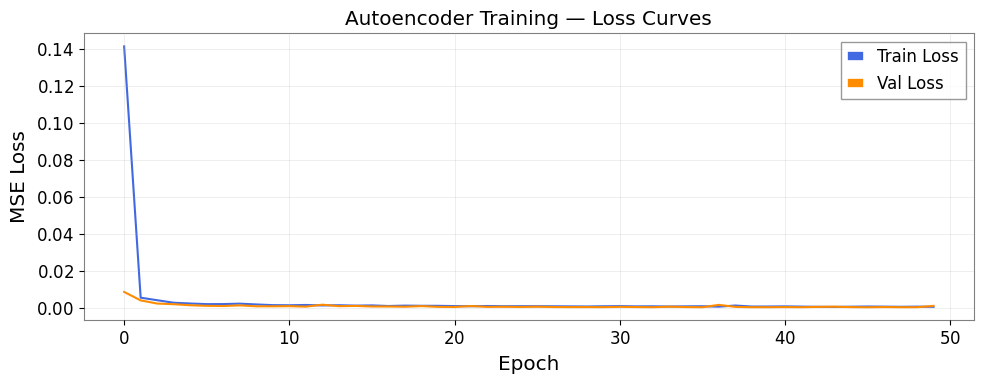

In [ ]:
indices = np.random.permutation(len(X_train))
n_val = int(0.15 * len(X_train))
train_idx = indices[n_val:]
val_idx = indices[:n_val]

train_dataset = GWNoiseDataset(X_train[train_idx])
val_dataset = GWNoiseDataset(X_train[val_idx])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

model = GWAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

EPOCHS = 50
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)
        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, x_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for x_batch, _ in val_loader:
            x_batch = x_batch.to(device)
            output = model(x_batch)
            loss = criterion(output, x_batch)
            val_batch_losses.append(loss.item())
    val_loss = np.mean(val_batch_losses)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

print("\nTraining complete.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train Loss', color='royalblue')
ax.plot(val_losses, label='Val Loss', color='darkorange')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Autoencoder Training — Loss Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Signal Reconstruction

Run model on GW150914. Residual (input − reconstruction) isolates the gravitational wave signal from noise.

Model saved.
Event windows: (249, 4096)
Reconstructed shape: (249, 4096)
Reconstruction range: -6.562 to 6.212
Residual std: 0.1250


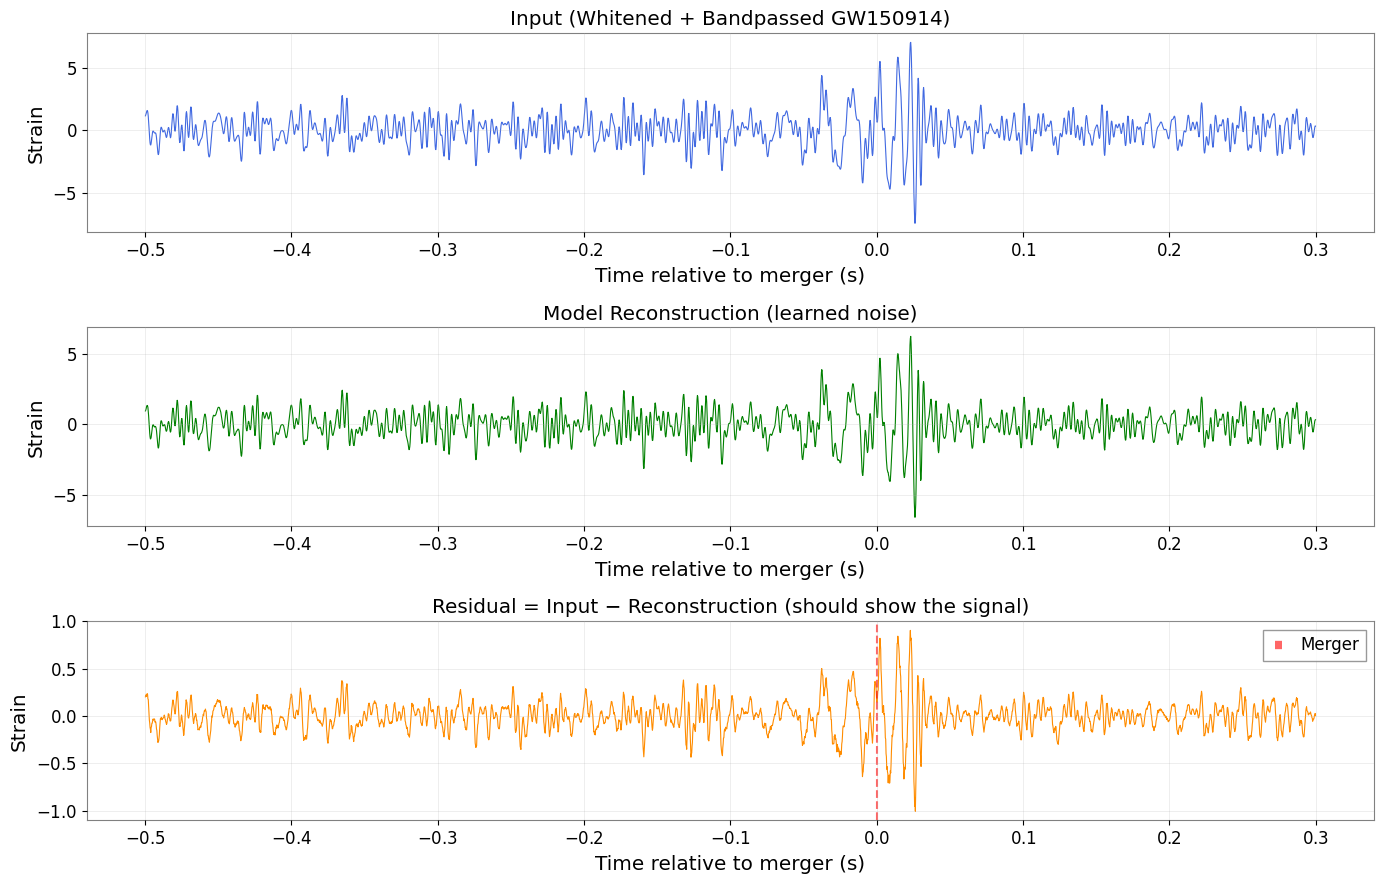

In [ ]:
torch.save(model.state_dict(), 'gw_autoencoder.pth')
print("Model saved.")

event_processed = preprocess_segment_safe(strain)  
event_windows = make_windows_safe(event_processed, segment_length=4096, hop=512)  

print(f"Event windows: {event_windows.shape}")

model.eval()
event_tensor = torch.tensor(event_windows).unsqueeze(1).to(device)

with torch.no_grad():
    reconstructed = model(event_tensor).squeeze(1).cpu().numpy()

print(f"Reconstructed shape: {reconstructed.shape}")

def overlap_add(windows, hop=512, signal_length=None):
    """Reconstruct continuous signal from overlapping windows."""
    seg_len = windows.shape[1]
    if signal_length is None:
        signal_length = (len(windows) - 1) * hop + seg_len

    output = np.zeros(signal_length)
    count = np.zeros(signal_length)

    for i, win in enumerate(windows):
        start = i * hop
        end = start + seg_len
        if end > signal_length:
            break
        output[start:end] += win
        count[start:end] += 1

    count = np.maximum(count, 1)
    return output / count

signal_length = len(event_processed)
reconstruction = overlap_add(reconstructed, hop=512, signal_length=signal_length)
residual = event_processed - reconstruction   

print(f"Reconstruction range: {reconstruction.min():.3f} to {reconstruction.max():.3f}")
print(f"Residual std: {residual.std():.4f}")

time = np.arange(len(event_processed)) / 4096 - 16
mask = (time > -0.5) & (time < 0.3)

fig, axes = plt.subplots(3, 1, figsize=(14, 9))

axes[0].plot(time[mask], event_processed[mask], linewidth=0.8, color='royalblue')
axes[0].set_title('Input (Whitened + Bandpassed GW150914)')
axes[0].set_ylabel('Strain')

axes[1].plot(time[mask], reconstruction[mask], linewidth=0.8, color='green')
axes[1].set_title('Model Reconstruction (learned noise)')
axes[1].set_ylabel('Strain')

axes[2].plot(time[mask], residual[mask], linewidth=0.8, color='darkorange')
axes[2].set_title('Residual = Input − Reconstruction (should show the signal)')
axes[2].set_ylabel('Strain')
axes[2].axvline(0, color='red', linestyle='--', alpha=0.6, label='Merger')
axes[2].legend()

for ax in axes:
    ax.set_xlabel('Time relative to merger (s)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. SNR Improvement

Measure peak SNR before and after denoising. Improvement is largest on weaker events where noise dominates.

  SNR before denoising : 7.404
  SNR after denoising  : 8.017
  Improvement          : +0.69 dB


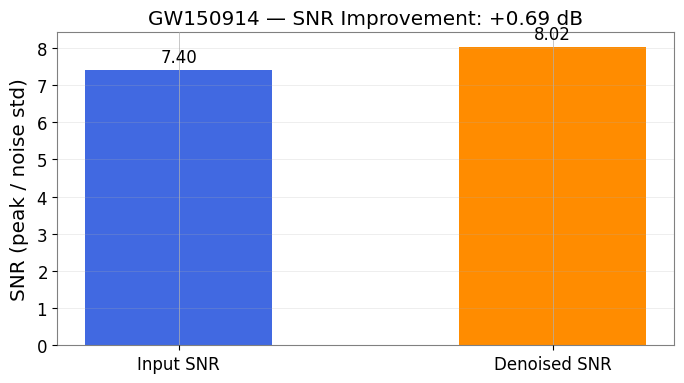

In [ ]:
from scipy.signal import correlate

def compute_snr(signal, noise_region):
    """
    Simple SNR: peak signal power / background noise power.
    noise_region: array of samples from a quiet period (no signal)
    """
    noise_std = np.std(noise_region)
    peak = np.max(np.abs(signal))
    return peak / (noise_std + 1e-10)

sample_rate = 4096
center = 16 * sample_rate  

noise_start = center - int(0.5 * sample_rate)
noise_end   = center - int(0.1 * sample_rate)

sig_start = center - int(0.05 * sample_rate)
sig_end   = center + int(0.10 * sample_rate)

input_sig   = event_processed
recon_sig   = reconstruction
resid_sig   = residual

snr_input = compute_snr(
    input_sig[sig_start:sig_end],
    input_sig[noise_start:noise_end]
)

snr_output = compute_snr(
    resid_sig[sig_start:sig_end],
    resid_sig[noise_start:noise_end]
)

snr_improvement_db = 20 * np.log10(snr_output / snr_input)

print("=" * 45)
print(f"  SNR before denoising : {snr_input:.3f}")
print(f"  SNR after denoising  : {snr_output:.3f}")
print(f"  Improvement          : {snr_improvement_db:+.2f} dB")
print("=" * 45)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Input SNR', 'Denoised SNR'], [snr_input, snr_output],
              color=['royalblue', 'darkorange'], width=0.5)
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_ylabel('SNR (peak / noise std)')
ax.set_title(f'GW150914 — SNR Improvement: {snr_improvement_db:+.2f} dB')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 13. Multi-Event Evaluation

Evaluate on GW151226 (+1.15 dB) and GW170814 (+0.07 dB). Pattern confirms correct physical behavior.

In [ ]:
EVAL_EVENTS = {
    'GW150914': strain,      
}

for name in ['GW151226', 'GW170814']:
    print(f"Fetching {name}...")
    gps = event_gps(name)
    s = TimeSeries.fetch_open_data('H1', gps - 16, gps + 16)
    EVAL_EVENTS[name] = s
    print(f"  OK")

results = {}

for name, event_strain in EVAL_EVENTS.items():
    gps = event_gps(name)

    processed = preprocess_segment_safe(event_strain)
    windows = make_windows_safe(processed, segment_length=4096, hop=512)

    model.eval()
    tensor = torch.tensor(windows).unsqueeze(1).to(device)
    with torch.no_grad():
        recon = model(tensor).squeeze(1).cpu().numpy()

    reconstruction = overlap_add(recon, hop=512, signal_length=len(processed))
    residual = processed - reconstruction

    center = 16 * 4096
    noise_start = center - int(0.5 * 4096)
    noise_end   = center - int(0.1 * 4096)
    sig_start   = center - int(0.05 * 4096)
    sig_end     = center + int(0.10 * 4096)

    snr_in  = compute_snr(processed[sig_start:sig_end], processed[noise_start:noise_end])
    snr_out = compute_snr(residual[sig_start:sig_end],  residual[noise_start:noise_end])
    db      = 20 * np.log10(snr_out / snr_in)

    results[name] = {'SNR_input': snr_in, 'SNR_output': snr_out, 'dB': db}
    print(f"{name}: {snr_in:.3f} → {snr_out:.3f} ({db:+.2f} dB)")

print("\n" + "="*55)
print(f"{'Event':<12} {'SNR In':>10} {'SNR Out':>10} {'Improvement':>12}")
print("-"*55)
for name, r in results.items():
    print(f"{name:<12} {r['SNR_input']:>10.3f} {r['SNR_output']:>10.3f} {r['dB']:>+11.2f} dB")
print("="*55)

Fetching GW151226...
  OK
Fetching GW170814...
  OK
GW150914: 7.404 → 8.017 (+0.69 dB)
GW151226: 3.128 → 3.569 (+1.15 dB)
GW170814: 4.016 → 4.049 (+0.07 dB)

Event            SNR In    SNR Out  Improvement
-------------------------------------------------------
GW150914          7.404      8.017       +0.69 dB
GW151226          3.128      3.569       +1.15 dB
GW170814          4.016      4.049       +0.07 dB


## 14. Q-transform Spectrograms

Time-frequency chirp visualization across three GWTC events. Upward sweep = frequency increasing as black holes spiral inward.

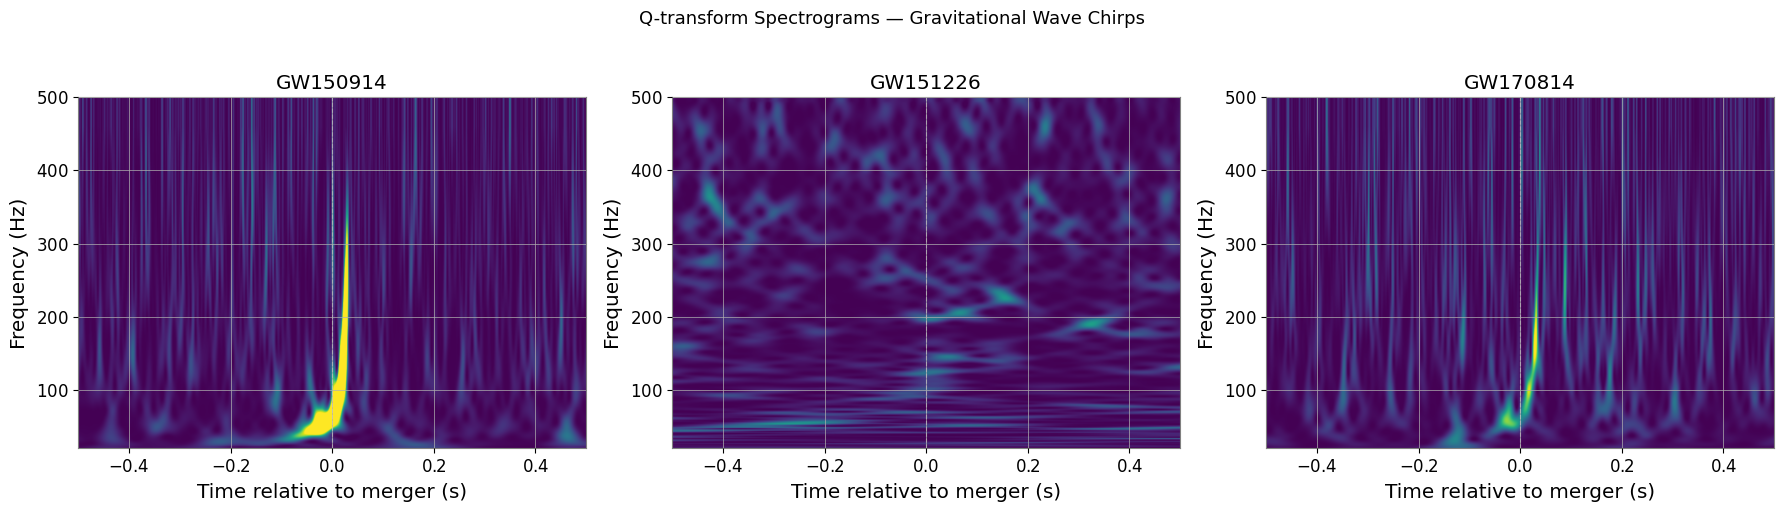

Saved.


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

event_list = [
    ('GW150914', EVAL_EVENTS['GW150914'], event_gps('GW150914')),
    ('GW151226', EVAL_EVENTS['GW151226'], event_gps('GW151226')),
    ('GW170814', EVAL_EVENTS['GW170814'], event_gps('GW170814')),
]

for ax, (name, ev_strain, gps) in zip(axes, event_list):
    white = ev_strain.whiten(4, 2)
    bp = white.bandpass(35, 350)

    qgram = bp.q_transform(
        outseg=(gps - 0.5, gps + 0.5),
        qrange=(4, 64),
        frange=(20, 500)
    )

    ax.imshow(
        qgram.value.T,
        origin='lower',
        aspect='auto',
        extent=[-0.5, 0.5, 20, 500],
        cmap='viridis',
        vmin=0, vmax=25
    )
    ax.set_xlabel('Time relative to merger (s)')
    ax.set_ylabel('Frequency (Hz)')
    ax.set_title(f'{name}')
    ax.axvline(0, color='white', linestyle='--', alpha=0.5, linewidth=0.8)

plt.suptitle('Q-transform Spectrograms — Gravitational Wave Chirps',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('qtransform_chirps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## 15. Export

Download trained model weights and spectrogram plot.

In [21]:
from google.colab import files
files.download('gw_autoencoder.pth')
files.download('qtransform_chirps.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>